<a href="https://colab.research.google.com/github/Pushpalatha-H/Anusikshan/blob/main/Anusikshan_3_AI_Data_Analyst_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit         # Used to buid web applications,directly from python
import streamlit as st         #
import pandas as pd            # import libraries for data manipulation
import numpy as np             # import libraries for data manipulation
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns          # for plotting

st.set_page_config(page_title="AI Data Analyst Agent", layout="wide")     # Configure the streamlit pages title and layout

st.title("🤖 AI Data Analyst Agent")     # Display the main title and a descriptive text on the web app.
st.write("Upload CSV/Excel, generate insights, visualize data, and ask questions.")

# -------------------------
# File Upload
# -------------------------
uploaded_file = st.file_uploader(          # Creates a widget for users to upload CSV or Excel files.
    "Upload CSV or Excel File",
    type=["csv","xlsx"]
)

if uploaded_file is not None:         # Block executes only when a file has been successfully uploaded.

    # Read File
    if uploaded_file.name.endswith(".csv"):   # it reads the uploaded file into a pandas, disinguish b/w csv & excel formats based on file extension
        df = pd.read_csv(uploaded_file)
    else:
        df = pd.read_excel(uploaded_file)

    st.subheader("Raw Dataset")
    st.dataframe(df.head())


    # -------------------------
    # Data Cleaning Agent
    # -------------------------
    st.subheader("Data Cleaning Agent")             # Introduces this section

    duplicate_rows = df.duplicated().sum()          # Count the number of duplicate rows
    missing_values = df.isnull().sum().sum()        # Count the number of missing values

    df.drop_duplicates(inplace=True)                # Removes duplicate rows directly from data frame

    numeric_cols = df.select_dtypes(include=np.number).columns    # identifies all numeric columns.

    for col in numeric_cols:                              # Fills missing values in numeric columns with their respictive median values.
        df[col].fillna(df[col].median(), inplace=True)

    st.write(f"Duplicates Removed: {duplicate_rows}")       # Displays numer of duplicates removed and missing values handled.
    st.write(f"Missing Values Handled: {missing_values}")

    # -------------------------
    # Insights Agent
    # -------------------------
    st.subheader("Auto Insights")          # Intoduces this session

    st.write("Shape:", df.shape)         # Shows the dimensions of the cleaned DataFrame

    st.write("Summary Statistics")     # Displays descriptive statistics for numerical columns.
    st.dataframe(df.describe())

    if len(numeric_cols) >= 2:            # It Calculates and displays the correlation matrix.
        corr = df[numeric_cols].corr()
        st.write("Correlation Matrix")
        st.dataframe(corr)

    # -------------------------
    # Visualization Agent
    # -------------------------
    st.subheader("Visualization Agent")    # Introduces this section.

    chart_col = st.selectbox(         # Allows the user to select a numeric column for visualization using a dropdown
        "Select Numeric Column",
        numeric_cols
    )

    fig, ax = plt.subplots()       # It then generates a histogram for the selected numeric column using matplotlib and displays it in streamlit.
    df[chart_col].hist(ax=ax)
    st.pyplot(fig)

    if len(numeric_cols) >=2:
        st.subheader("Heatmap")
        fig2, ax2 = plt.subplots()
        sns.heatmap(df[numeric_cols].corr(), annot=True, ax=ax2)         # showing the relationships b/w numeric variables
        st.pyplot(fig2)

    # -------------------------
    # Natural Language Query Agent
    # -------------------------
    st.subheader("Ask Questions About Data")          # This section provides a text input field where users can ask questions about the data.

    question = st.text_input(
        "Example: Which region had highest sales?"   # It includes a basic nlp capability to respond to queries about 'highest'(max), 'average'(mean)
    )

    if question:

        q=question.lower()

        if "highest" in q or "max" in q:
            for col in numeric_cols:
                max_row = df.loc[df[col].idxmax()]
                st.success(
                    f"{col} highest value is {max_row[col]}"
                )
                break

        elif "average" in q or "mean" in q:
            for col in numeric_cols:
                st.success(
                    f"Average {col}: {df[col].mean()}"
                )
                break

        elif "correlation" in q:
            st.write(df[numeric_cols].corr())

        else:
            st.warning(
              "Demo version supports highest, average, and correlation queries."
            )

    # -------------------------
    # Recommendation Agent
    # -------------------------
    st.subheader("AI Recommendations")

    if len(numeric_cols)>0:
        for col in numeric_cols:
            if df[col].mean() > df[col].median():
                st.write(
                 f"• {col} shows upward trend worth monitoring."
                )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.6 MB/s eta 0:00:00


2026-04-29 09:26:29.870 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 09:26:29.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 09:26:30.155 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-29 09:26:30.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 09:26:30.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 09:26:30.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 09:26:30.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
%%writefile app.py
# paste the full project code below this line

Writing app.py


In [ ]:
!pip install streamlit seaborn openpyxl -q

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-04-29 09:44:42.852 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.58.12:8501

y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://olive-webs-grin.loca.lt
  Stopping...
^C


Saving ISF Beneficiary Database - Govt PU College NewFort (1).xlsx to ISF Beneficiary Database - Govt PU College NewFort (1).xlsx
Dataset Preview


,S.No,School Name,School Type,UDISE No.,City/Village,Taluka,District,State,CSR Partner,Type of Intervention,...,Total Students supported,School Trainer/ Coordinator Name,School Trainer/ Coordinator Contact Number,ISF Trainer Name,ISF Trainer Contact Number,School HM Name,School HM Contact Number,AHM Name,AHM Contact,School Email Address
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,Govt PU College NewFort,Govt,2.927013e+10,Chamrajpet,Bengaluru,Bengaluru,Karnataka,Amadeus Software Labs,Anushikshan,...,117.0,Nagabushan N,9.741905e+09,Pushpalatha H,8.073409e+09,Narayanappa M,9.448574e+09,-,-,gpucas@gmail.com



Cleaning Data...
Duplicates removed: 0

Summary Statistics


/tmp/ipykernel_14464/1021381943.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,S.No,UDISE No.,No. of Teachers,No. of Boys,No. of Girls,Total Students,No. of Teachers supported,No. of Boys supported,No. of Girls supported,Total Students supported,School Trainer/ Coordinator Contact Number,ISF Trainer Contact Number,School HM Contact Number
count,2.0,2.000000e+00,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.000000e+00,2.000000e+00,2.000000e+00
mean,1.0,2.927013e+10,10.0,75.0,42.0,117.0,10.0,75.0,42.0,117.0,9.741905e+09,8.073409e+09,9.448574e+09
std,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
min,1.0,2.927013e+10,10.0,75.0,42.0,117.0,10.0,75.0,42.0,117.0,9.741905e+09,8.073409e+09,9.448574e+09
25%,1.0,2.927013e+10,10.0,75.0,42.0,117.0,10.0,75.0,42.0,117.0,9.741905e+09,8.073409e+09,9.448574e+09
50%,1.0,2.927013e+10,10.0,75.0,42.0,117.0,10.0,75.0,42.0,117.0,9.741905e+09,8.073409e+09,9.448574e+09
75%,1.0,2.927013e+10,10.0,75.0,42.0,117.0,10.0,75.0,42.0,117.0,9.741905e+09,8.073409e+09,9.448574e+09
max,1.0,2.927013e+10,10.0,75.0,42.0,117.0,10.0,75.0,42.0,117.0,9.741905e+09,8.073409e+09,9.448574e+09


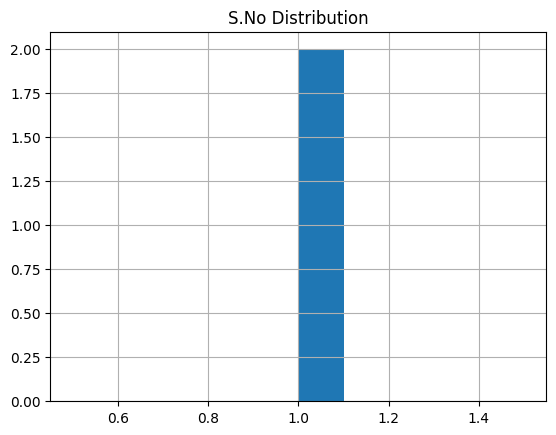

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


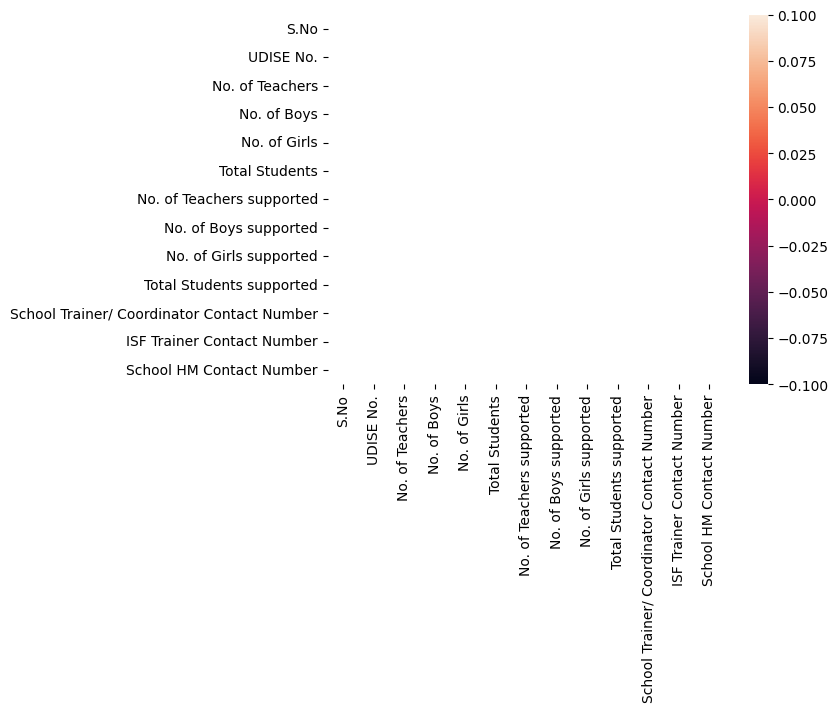

Ask question (highest sales / average / correlation): lowest

Recommendations:


In [ ]:
# Correct
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload file
from google.colab import files
uploaded = files.upload()

# Read uploaded file
filename=list(uploaded.keys())[0]

if filename.endswith(".csv"):
    df=pd.read_csv(filename)
else:
    df=pd.read_excel(filename)

print("Dataset Preview")
display(df.head())

# -------------------
# Data Cleaning Agent
# -------------------

print("\nCleaning Data...")

duplicates=df.duplicated().sum()
df.drop_duplicates(inplace=True)

num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Duplicates removed:",duplicates)

# -------------------
# Insights Agent
# -------------------

print("\nSummary Statistics")
display(df.describe())

# -------------------
# Visualization Agent
# -------------------

for col in num_cols[:1]:
    plt.figure()
    df[col].hist()
    plt.title(f"{col} Distribution")
    plt.show()

# -------------------
# Correlation Heatmap
# -------------------

if len(num_cols)>=2:
    import seaborn as sns
    plt.figure()
    sns.heatmap(df[num_cols].corr(),annot=True)
    plt.show()

# -------------------
# Simple Query Agent
# -------------------

question=input(
"Ask question (highest sales / average / correlation): "
).lower()

if "highest" in question:
    col=num_cols[0]
    print(
      f"Highest {col}:",
      df[col].max()
    )

elif "average" in question:
    col=num_cols[0]
    print(
      f"Average {col}:",
      df[col].mean()
    )

elif "correlation" in question:
    display(df[num_cols].corr())

# -------------------
# Recommendations
# -------------------

print("\nRecommendations:")
for col in num_cols:
    if df[col].mean()>df[col].median():
        print(
         f"{col} shows upward trend worth monitoring."
        )